# Demand Pattern Evaluation

This notebook checks how each model performs on Regular, Irregular, and 
Intermittent demand separately, using the blind 15-day forecast results 
from the forecasting notebook. The goal is to answer the project's main 
question: does one model work best everywhere, or does the best choice 
depend on the demand pattern?


## 1. Setup and Data Loading

This section loads the required libraries and the model evaluation outputs generated during the forecasting stage.

In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Loading the Prediction Data

We load the row-level predictions saved from the forecasting notebook, after the blind-forecast correction. This file contains the actual sales, demand patterns, and predictions from all five evaluated models.

In [8]:
predictions_df = pd.read_parquet("../data/processed/final_prediction_results.parquet")

print(predictions_df.shape)
print(predictions_df["pattern"].value_counts())
predictions_df.head()

(25920, 10)
pattern
Regular         16920
Irregular        5670
Intermittent     3330
Name: count, dtype: int64


,date,store_nbr,family,sales,pattern,seasonal_naive_pred,xgboost_pred,lightgbm_pred,xgboost_tuned_pred,lightgbm_tuned_pred
0,2017-08-01,1,AUTOMOTIVE,5.0,Regular,10.0,4.567134,5.747949,5.312187,6.269504
1,2017-08-02,1,AUTOMOTIVE,4.0,Regular,2.0,3.010375,3.440070,4.313983,4.746142
2,2017-08-03,1,AUTOMOTIVE,3.0,Regular,5.0,2.721760,3.051329,4.203620,2.040151
3,2017-08-04,1,AUTOMOTIVE,8.0,Regular,7.0,2.846117,5.004899,4.429359,3.389619
4,2017-08-05,1,AUTOMOTIVE,5.0,Regular,4.0,4.485727,8.958764,5.187583,8.547551


## 2. Data Quality Checks

Before calculating any metrics, we check the data for missing values, 
duplicates, and negative values, since any of these would distort the 
per-pattern results.

In [9]:
print("Missing values:")
print(predictions_df.isna().sum())

print("\nDuplicate rows:", predictions_df.duplicated().sum())

print("\nNegative actual sales:", (predictions_df["sales"] < 0).sum())
print("\nNegative predictions:")
print((predictions_df[["seasonal_naive_pred", "xgboost_pred", "lightgbm_pred"]] < 0).sum())

Missing values:
date                   0
store_nbr              0
family                 0
sales                  0
pattern                0
seasonal_naive_pred    0
xgboost_pred           0
lightgbm_pred          0
xgboost_tuned_pred     0
lightgbm_tuned_pred    0
dtype: int64

Duplicate rows: 0

Negative actual sales: 0

Negative predictions:
seasonal_naive_pred    0
xgboost_pred           0
lightgbm_pred          0
dtype: int64


### Insight

The data has no missing values, no duplicates, and no negative numbers 
anywhere. This confirms the prediction table is clean and ready to use 
for the pattern-level comparison.

## 3. Performance by Demand Pattern

This section calculates RMSLE, MAE, and RMSE for each model, separately 
for Regular, Irregular, and Intermittent demand. RMSLE is the main 
metric, since it handles the zero-heavy, skewed sales data better than 
MAE or RMSE alone.

In [10]:
import sys
sys.path.append("../")
from src.evaluation import evaluate

models = {
    "Seasonal Naive": "seasonal_naive_pred",
    "XGBoost": "xgboost_pred",
    "LightGBM": "lightgbm_pred",
    "XGBoost Tuned": "xgboost_tuned_pred",
    "LightGBM Tuned": "lightgbm_tuned_pred"
}

pattern_results = []

for pattern in predictions_df["pattern"].unique():
    subset = predictions_df[predictions_df["pattern"] == pattern]
    
    for model_name, pred_col in models.items():
        result = evaluate(subset["sales"], subset[pred_col], name=model_name)
        result["Pattern"] = pattern
        pattern_results.append(result)

pattern_metrics = pd.DataFrame(pattern_results)[["Pattern", "Model", "RMSLE", "MAE", "RMSE"]]
pattern_metrics

Seasonal Naive       MAE:   145.59 | RMSE:   445.99 | RMSLE: 0.5127 | WMAPE:  20.90%
XGBoost              MAE:   122.09 | RMSE:   345.04 | RMSLE: 0.4763 | WMAPE:  17.53%
LightGBM             MAE:   125.64 | RMSE:   354.08 | RMSLE: 0.4476 | WMAPE:  18.04%
XGBoost Tuned        MAE:   122.19 | RMSE:   348.42 | RMSLE: 0.4185 | WMAPE:  17.54%
LightGBM Tuned       MAE:   124.26 | RMSE:   355.30 | RMSLE: 0.4530 | WMAPE:  17.84%
Seasonal Naive       MAE:     1.00 | RMSE:     3.89 | RMSLE: 0.6156 | WMAPE:  97.02%
XGBoost              MAE:     0.99 | RMSE:     3.20 | RMSLE: 0.5746 | WMAPE:  96.11%
LightGBM             MAE:     1.75 | RMSE:     3.40 | RMSLE: 0.8400 | WMAPE: 169.96%
XGBoost Tuned        MAE:     1.47 | RMSE:     5.71 | RMSLE: 0.5651 | WMAPE: 143.34%
LightGBM Tuned       MAE:     1.30 | RMSE:     4.95 | RMSLE: 0.6316 | WMAPE: 126.89%
Seasonal Naive       MAE:    30.22 | RMSE:    89.92 | RMSLE: 0.8725 | WMAPE:  26.60%
XGBoost              MAE:    27.00 | RMSE:    81.32 | RMSLE: 0.76

,Pattern,Model,RMSLE,MAE,RMSE
0,Regular,Seasonal Naive,0.512734,145.593066,445.990868
1,Regular,XGBoost,0.476281,122.085107,345.038765
2,Regular,LightGBM,0.447566,125.639483,354.080195
3,Regular,XGBoost Tuned,0.418529,122.194683,348.418791
4,Regular,LightGBM Tuned,0.452956,124.263447,355.295001
5,Intermittent,Seasonal Naive,0.615612,0.996997,3.889000
6,Intermittent,XGBoost,0.574606,0.987670,3.201234
7,Intermittent,LightGBM,0.839973,1.746557,3.399336
8,Intermittent,XGBoost Tuned,0.565106,1.473013,5.707758
9,Intermittent,LightGBM Tuned,0.631580,1.304004,4.946577


### Insight

The results above include both baseline and tuned models. Hyperparameter tuning improved XGBoost's RMSLE across all three demand patterns, while the effect on LightGBM varied by pattern.

The final model comparison below uses the updated five-model results.

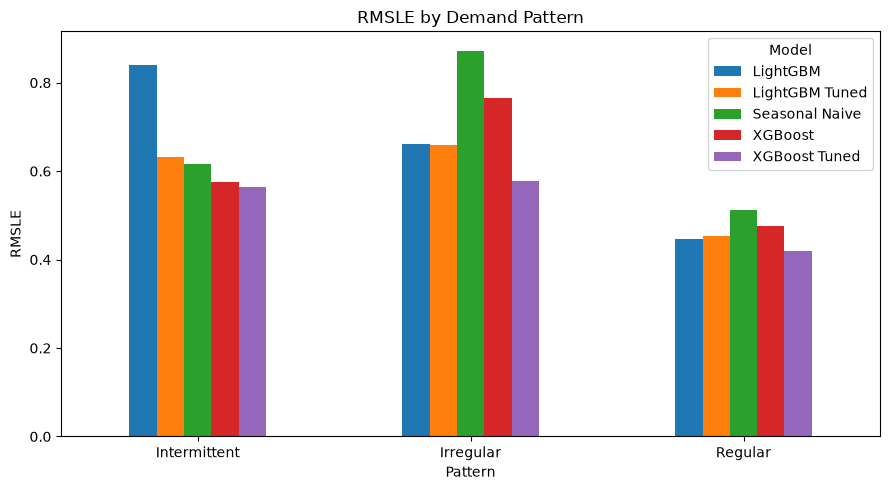

In [11]:
import matplotlib.pyplot as plt

pattern_metrics.pivot(
    index="Pattern",
    columns="Model",
    values="RMSLE"
).plot(kind="bar", figsize=(9, 5))

plt.ylabel("RMSLE")
plt.title("RMSLE by Demand Pattern")
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.tight_layout()
plt.show()

### Insight

The chart shows that XGBoost Tuned achieves the lowest RMSLE across all three demand patterns.

For XGBoost, tuning improves RMSLE from 0.476 to 0.419 on Regular demand, from 0.766 to 0.579 on Irregular demand, and from 0.575 to 0.565 on Intermittent demand.

For LightGBM, the effect of tuning varies by pattern, with improvements on Irregular and Intermittent demand but a small increase in RMSLE on Regular demand.

## 4. Best Model per Pattern

This section pulls out the single best model for each demand pattern, 
based on RMSLE, into one clear table.

In [12]:
best_models = pattern_metrics.loc[
    pattern_metrics.groupby("Pattern")["RMSLE"].idxmin()
]

best_models

,Pattern,Model,RMSLE,MAE,RMSE
8,Intermittent,XGBoost Tuned,0.565106,1.473013,5.707758
13,Irregular,XGBoost Tuned,0.578600,26.408474,80.919184
3,Regular,XGBoost Tuned,0.418529,122.194683,348.418791


### Insight

Based on RMSLE, XGBoost Tuned achieves the lowest error across all three demand patterns in the current five-model comparison.

This shows that hyperparameter tuning improved XGBoost's performance across Regular, Irregular, and Intermittent demand.

These results represent the current five-model comparison. DeepAR will be evaluated separately before the final model selection.

## 5. Intermittent Demand by Family

This section checks model performance within the Intermittent group at 
the family level, to see if the best model is consistent across 
families or changes from one family to another.

In [13]:
intermittent_df = predictions_df[
    predictions_df["pattern"] == "Intermittent"
].copy()

family_results = []

for family in intermittent_df["family"].unique():
    subset = intermittent_df[
        intermittent_df["family"] == family
    ]

    for model_name, pred_col in models.items():
        result = evaluate(
            subset["sales"],
            subset[pred_col],
            name=model_name
        )

        result["Family"] = family
        family_results.append(result)

family_metrics = pd.DataFrame(family_results)

family_metrics = family_metrics[
    ["Family", "Model", "RMSLE", "MAE", "RMSE"]
]

family_metrics.sort_values(
    ["Family", "RMSLE"]
).reset_index(drop=True)

Seasonal Naive       MAE:     0.05 | RMSE:     0.25 | RMSLE: 0.1634 | WMAPE: 212.50%
XGBoost              MAE:     0.25 | RMSE:     0.65 | RMSLE: 0.3814 | WMAPE: 997.62%
LightGBM             MAE:     1.41 | RMSE:     1.96 | RMSLE: 0.8778 | WMAPE: 5533.60%
XGBoost Tuned        MAE:     0.63 | RMSE:     0.66 | RMSLE: 0.4936 | WMAPE: 2486.51%
LightGBM Tuned       MAE:     0.48 | RMSE:     1.11 | RMSLE: 0.5247 | WMAPE: 1896.21%
Seasonal Naive       MAE:     0.30 | RMSE:     0.69 | RMSLE: 0.3932 | WMAPE: 229.55%
XGBoost              MAE:     0.32 | RMSE:     0.73 | RMSLE: 0.4213 | WMAPE: 248.16%
LightGBM             MAE:     1.45 | RMSE:     2.01 | RMSLE: 0.8843 | WMAPE: 1113.68%
XGBoost Tuned        MAE:     0.63 | RMSE:     0.69 | RMSLE: 0.4865 | WMAPE: 485.78%
LightGBM Tuned       MAE:     0.56 | RMSE:     1.17 | RMSLE: 0.5499 | WMAPE: 431.56%
Seasonal Naive       MAE:     2.62 | RMSE:     8.87 | RMSLE: 0.9629 | WMAPE:  89.85%
XGBoost              MAE:     2.54 | RMSE:     7.14 | RMSLE: 

,Family,Model,RMSLE,MAE,RMSE
0,BABY CARE,Seasonal Naive,0.419037,0.341667,0.767029
1,BABY CARE,XGBoost,0.471724,0.403404,0.833923
2,BABY CARE,XGBoost Tuned,0.493997,0.665125,0.755440
3,BABY CARE,LightGBM Tuned,0.582787,0.628782,1.238374
4,BABY CARE,LightGBM,0.875468,1.445049,2.013453
5,BEAUTY,LightGBM Tuned,0.607683,1.005266,1.585933
6,BEAUTY,XGBoost,0.624184,0.928095,1.454162
7,BEAUTY,XGBoost Tuned,0.763953,1.626386,2.211170
8,BEAUTY,Seasonal Naive,0.782846,1.346667,1.865476
9,BEAUTY,LightGBM,0.812711,1.806535,2.323661


In [14]:
best_family_models = family_metrics.loc[
    family_metrics.groupby("Family")["RMSLE"].idxmin()
]

print(best_family_models.sort_values("RMSLE"))
print("\nWin count:")
print(best_family_models["Model"].value_counts())

                        Family           Model     RMSLE       MAE      RMSE
0                        BOOKS  Seasonal Naive  0.163433  0.053968  0.245596
5              HOME APPLIANCES  Seasonal Naive  0.393190  0.299259  0.690679
15                   BABY CARE  Seasonal Naive  0.419037  0.341667  0.767029
23                    HARDWARE   XGBoost Tuned  0.499248  0.771346  0.991023
26             LAWN AND GARDEN         XGBoost  0.534266  1.338482  2.899341
38                PET SUPPLIES   XGBoost Tuned  0.542152  0.993321  1.355049
43                  LADIESWEAR   XGBoost Tuned  0.546387  1.251455  1.867382
53     PLAYERS AND ELECTRONICS   XGBoost Tuned  0.549788  0.961401  1.432835
33                   MAGAZINES   XGBoost Tuned  0.565002  1.031427  1.410987
49                      BEAUTY  LightGBM Tuned  0.607683  1.005266  1.585933
11  SCHOOL AND OFFICE SUPPLIES         XGBoost  0.653682  2.539478  7.136247
58                     SEAFOOD   XGBoost Tuned  0.752007  1.528604  1.982469

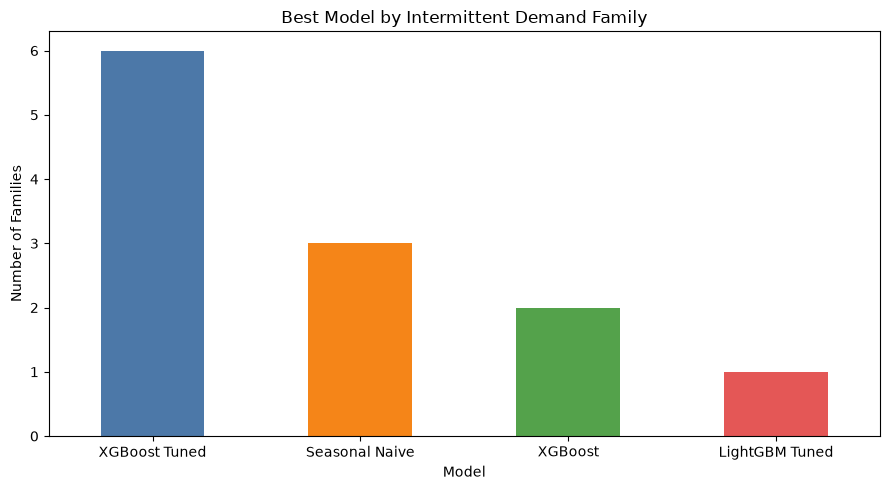

In [18]:
win_counts = best_family_models["Model"].value_counts()

ax = win_counts.plot(
    kind="bar",
    figsize=(9, 5),
    color=["#4C78A8", "#F58518", "#54A24B", "#E45756", "#B279A2"]
)

plt.ylabel("Number of Families")
plt.xlabel("Model")
plt.title("Best Model by Intermittent Demand Family")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight

The family-level results show that the best model varies across intermittent demand families.

XGBoost Tuned achieves the lowest RMSLE in 6 of the 12 families, followed by Seasonal Naive in 3 families, XGBoost in 2 families, and LightGBM Tuned in 1 family.

This shows that the best-performing model can differ between individual families, even within the same demand pattern. Therefore, evaluating intermittent demand at the family level provides additional insight beyond the overall pattern-level comparison.

## 6. Final Summary

In [15]:
final_results = pattern_metrics.pivot(
    index="Pattern",
    columns="Model",
    values="RMSLE"
)

final_results

Model,LightGBM,LightGBM Tuned,Seasonal Naive,XGBoost,XGBoost Tuned
Pattern,,,,,
Intermittent,0.839973,0.631580,0.615612,0.574606,0.565106
Irregular,0.660347,0.658796,0.872471,0.765809,0.578600
Regular,0.447566,0.452956,0.512734,0.476281,0.418529


## 7. Conclusion

The updated five-model comparison shows that XGBoost Tuned achieves the lowest RMSLE across all three demand patterns: Regular (0.419), Irregular (0.579), and Intermittent (0.565).

Hyperparameter tuning improved XGBoost's RMSLE across all three demand patterns compared with the baseline XGBoost model. The improvement is particularly noticeable for Irregular demand, where RMSLE decreased from 0.766 to 0.579.

However, the family-level analysis of intermittent demand shows that model performance still varies across individual families. XGBoost Tuned achieves the lowest RMSLE in 6 of the 12 intermittent families, while Seasonal Naive, XGBoost, and LightGBM Tuned perform best in some of the remaining families.

These results highlight the importance of both hyperparameter tuning and family-level evaluation, especially for intermittent demand. DeepAR will be evaluated separately before the final model comparison and selection.

## 8. Final Validation

Before saving the results, we run a final check to confirm that the prediction table and evaluation results are complete and valid.

In [19]:
print("Prediction rows:", len(predictions_df))
print("Missing values:", predictions_df.isna().sum().sum())
print("Duplicate rows:", predictions_df.duplicated().sum())
print("Negative actual sales:", (predictions_df["sales"] < 0).sum())

print(
    "Negative predictions:",
    (
        predictions_df[
            [
                "seasonal_naive_pred",
                "xgboost_pred",
                "lightgbm_pred",
                "xgboost_tuned_pred",
                "lightgbm_tuned_pred"
            ]
        ] < 0
    ).sum().sum()
)

Prediction rows: 25920
Missing values: 0
Duplicate rows: 0
Negative actual sales: 0
Negative predictions: 0


### Final Check Insight

The final prediction table contains 25,920 observations for the 15-day validation period. All five model predictions are complete, with no missing values, duplicate rows, negative actual sales, or negative predictions.

## 9. Save Evaluation Results

The final evaluation results are saved so they can be reused by the
project's reporting and downstream analysis stages.

In [20]:
pattern_metrics.to_csv("../outputs/forecasts/pattern_level_metrics.csv", index=False)
family_metrics.to_csv("../outputs/forecasts/intermittent_family_metrics.csv", index=False)
best_family_models.to_csv("../outputs/forecasts/intermittent_best_model_by_family.csv", index=False)

print("Saved:")
print("- pattern_level_metrics.csv:", pattern_metrics.shape)
print("- intermittent_family_metrics.csv:", family_metrics.shape)
print("- intermittent_best_model_by_family.csv:", best_family_models.shape)

Saved:
- pattern_level_metrics.csv: (15, 5)
- intermittent_family_metrics.csv: (60, 5)
- intermittent_best_model_by_family.csv: (12, 5)


## 10. End of Demand Pattern Evaluation

This notebook evaluated five forecasting models — Seasonal Naive, XGBoost, LightGBM, XGBoost Tuned, and LightGBM Tuned — across Regular, Irregular, and Intermittent demand patterns.

The results show that hyperparameter tuning improved XGBoost performance across all three demand patterns, while family-level evaluation shows that model performance can still vary across individual intermittent families.